# I. Installation des dépendances

In [3]:
!sudo apt-get update
!sudo apt-get install p7zip*
!pip install -r requirements.txt
!conda install -y graph-tool

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Hit:3 https://ppa.launchpadcontent.net/git-core/ppa/ubuntu jammy InRelease     
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://apt.postgresql.org/pub/repos/apt jammy-pgdg InRelease [129 kB]   
Get:7 https://apt.postgresql.org/pub/repos/apt jammy-pgdg/main amd64 Packages [580 kB]
Fetched 966 kB in 1s (724 kB/s)  
Reading package lists... Done
W: https://apt.postgresql.org/pub/repos/apt/dists/jammy-pgdg/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'p7zip-rar' for glob 'p7zip*'
Note, selecting 'p7zip-full' for glob 'p7zip*'
Note, selecting

# II. Récupération et traitement des données

Les données téléchargées occupent beaucoup d'espace (prévoir au moins 20 Go)

Nous commençons par les données d'OpenStreetMap.
Nous récupérons le graphe du réseau routier de New York, le projetons selon EPSG:32618, ajoutons des métadonnées utiles et le renumérotons.

In [399]:
import osmnx
import networkx
import solver
import data_management
import data_processing


osmnx.settings.log_console = True
osmnx.settings.use_cache = True

graph = osmnx.graph.graph_from_place("New York", network_type="drive")
graph = osmnx.project_graph(graph)
graph = osmnx.routing.add_edge_speeds(graph)
graph = osmnx.routing.add_edge_travel_times(graph)
graph = networkx.convert_node_labels_to_integers(graph)

Puis nous téléchargeons les données du traffic newyorkais. \
Nous nettyons le jeu de données sur les trajets des taxis, en enlevant notamment les valeurs aberrantes (voir la fonction clean_thread_job du fichier data_management.py pour plus de détails). \
Enfin, nous assignons à chaque point de récupération et de dépôt des trajets de taxis l'intersection de rue la plus proche, afin de faciliter le traitement par la suite.

In [ ]:
data_management.download_datasets("data")
data_management.clean_datasets("data/FOIL2013")
data_processing.preprocess_datasets(graph, "data/FOIL2013")

# II. Statistiques descriptives

Commençons par voir à quoi ressemble le réseau.

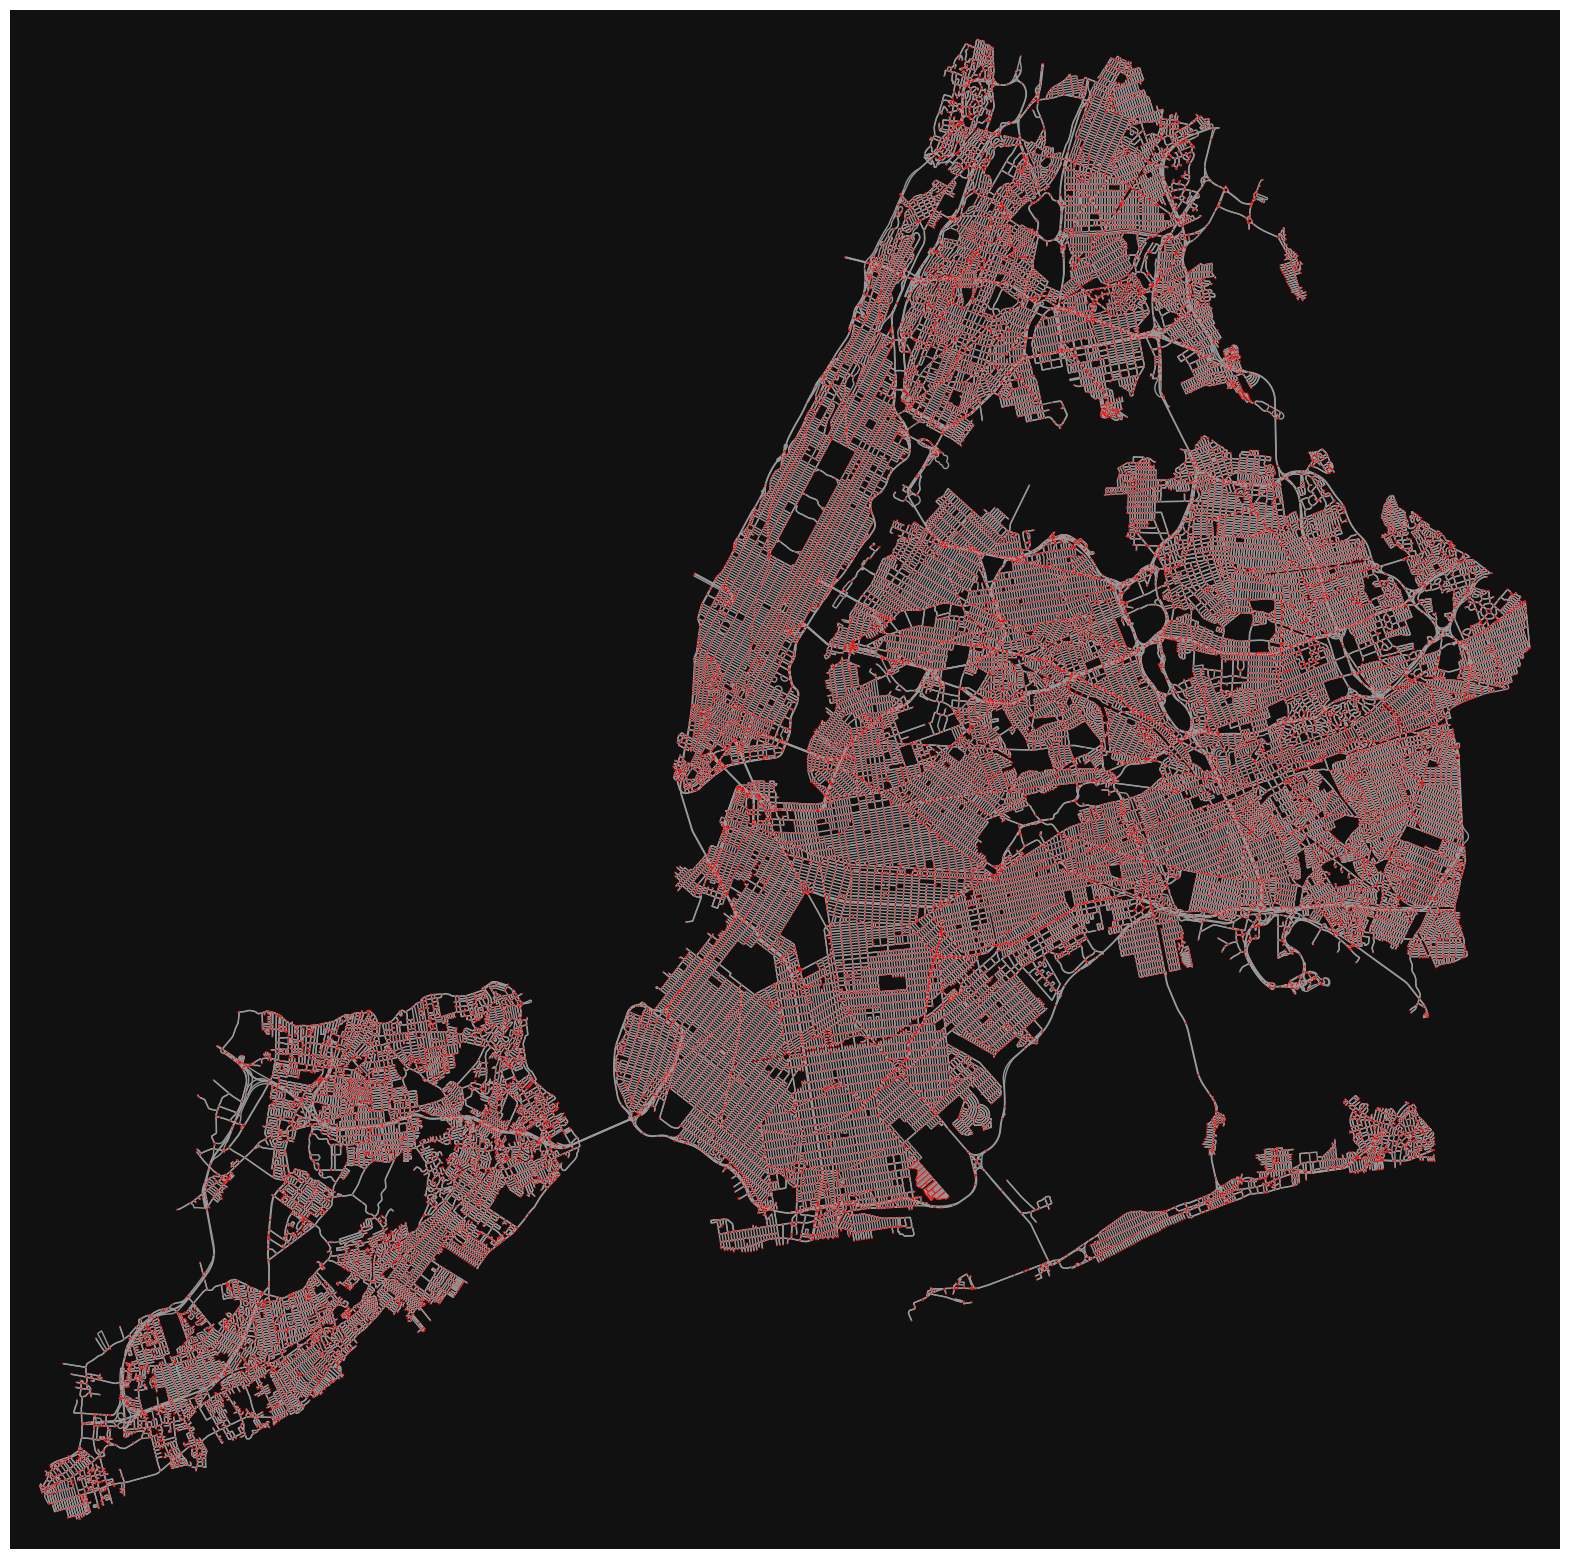

(<Figure size 2000x2000 with 1 Axes>, <Axes: >)

In [9]:
osmnx.plot.plot_graph(graph, node_size=1, figsize=(20, 20), node_color="#ff0000")

Regardons déjà quelle est la taille du réseau considéré : nombre de nœuds, nombre d'arêtes, degré moyen et longueur totale.

In [82]:
stats = osmnx.stats.basic_stats(graph)
print(f"Nombre de nœuds : {stats["n"]}")
print(f"Nombre d'arêtes : {stats["m"]}")
print(f"Degré moyen : {stats["k_avg"]}")
print(f"Longueur totale des rues : {stats["street_length_total"]}")

Nombre de nœuds : 55299
Nombre d'arêtes : 139461
Degré moyen : 5.04388867791461
Longueur totale des rues : 11185493.666439602


Les trois premières grandeurs rendent comptent de la complexité du réseau, et seront importantes par la suite lors de la modélisation. En effet, le solveur est assez lent donc il est crucial de garder le réseau simple. Il est actuellement trop grand, essayons de le simplifier en fusionnant les nœuds à une distance inférieure à 40m.

Nombre de nœuds : 16482
Nombre d'arêtes : 67701
Degré moyen : 8.215143793228977


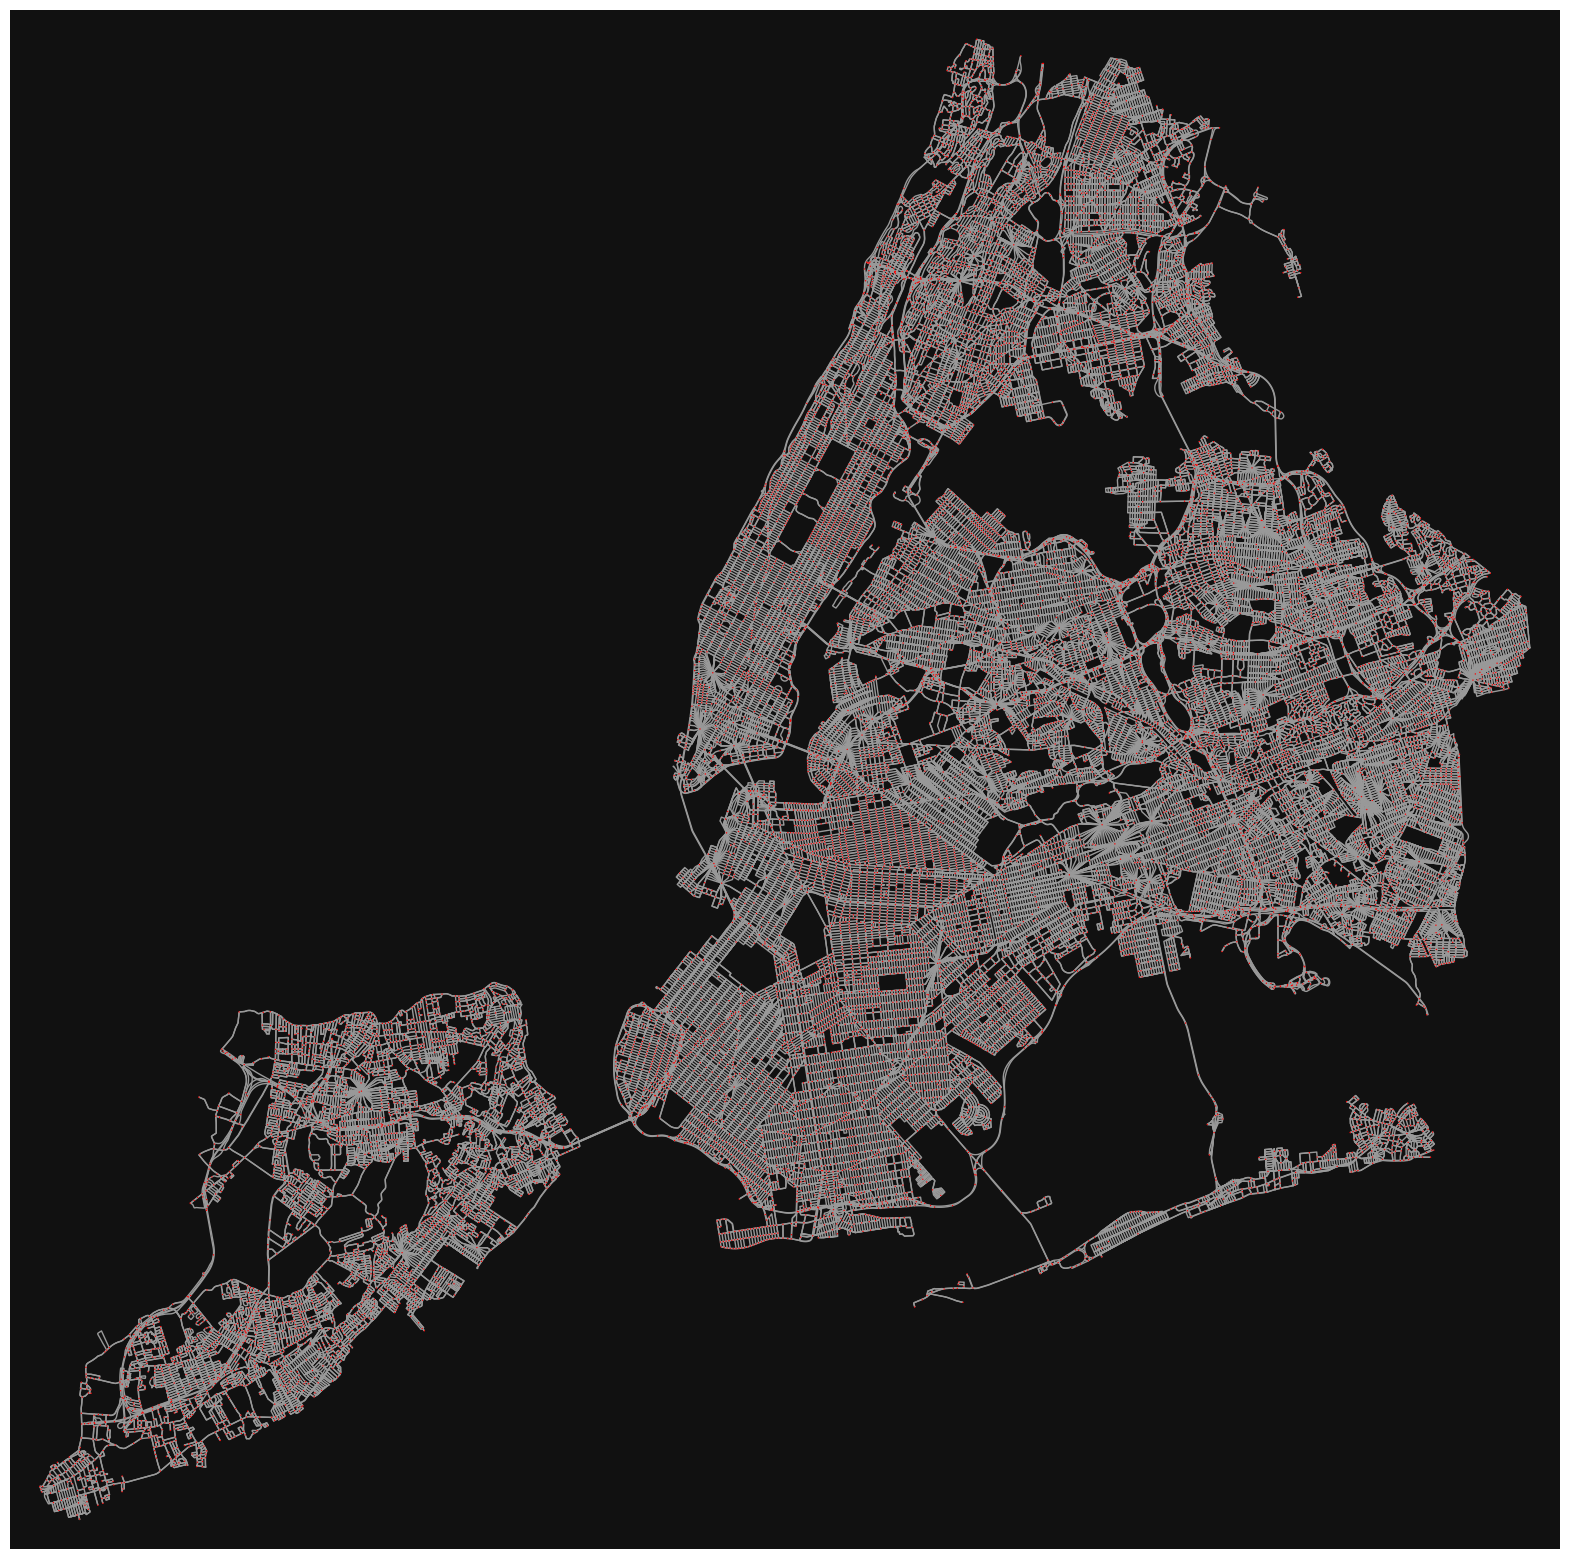

(<Figure size 2000x2000 with 1 Axes>, <Axes: >)

In [228]:
simplified_graph = osmnx.simplification.consolidate_intersections(graph, tolerance=40)
stats = osmnx.stats.basic_stats(simplified_graph)
print(f"Nombre de nœuds : {stats["n"]}")
print(f"Nombre d'arêtes : {stats["m"]}")
print(f"Degré moyen : {stats["k_avg"]}")
osmnx.plot.plot_graph(simplified_graph, node_size=1, figsize=(20, 20), node_color="#ff0000")

Nous avons réduit de 70% le nombre de nœuds et de 50% celui des arêtes tout en déformant assez peu le réseau (on peut néanmoins observer quelques artefacts en "étoile"). Cependant, le réseau simplifié est plus dense. Les statistiques descriptives se feront sur le graphe original. \
Intéressons nous maintenant aux déplacements des taxis. En moyenne, au cours de l'année entière, comment se répartissent-ils dans la ville ?

Nombre total de trajets :  71851956686.0


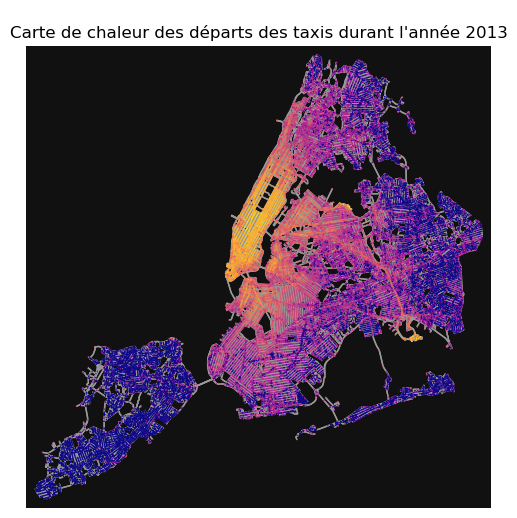

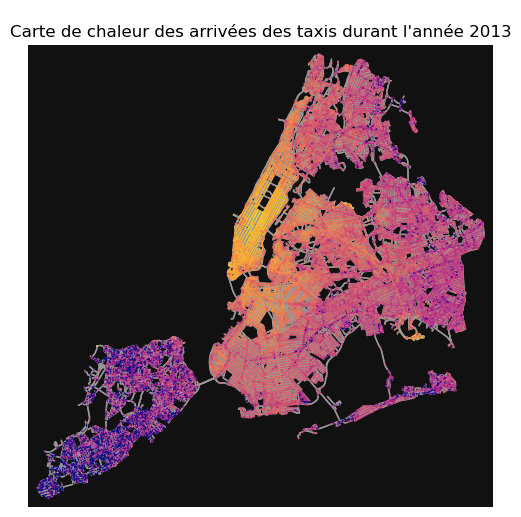

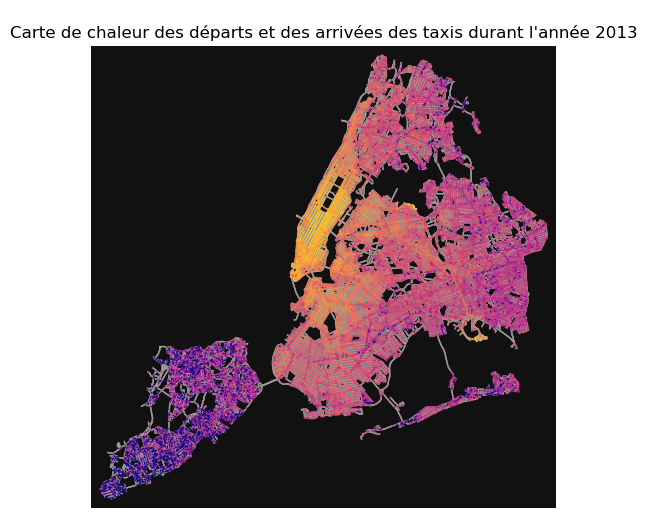

In [91]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

start_date = np.datetime64("2013-01-01")
end_date = np.datetime64("2013-12-31")
dates = pd.DataFrame({"start": [start_date], "end": [end_date]})
od_matrix = data_processing.build_raw_od_matrix("data/FOIL2013", dates, graph.order(), norm=False) # La coordonée (i, j) de cette matrice contient le nombre de trajets du sommet i vers le sommet j
# après normalisation
o_matrix = np.sum(od_matrix, axis=1) # Vecteur donnant le nombre de trajets partant d'un sommet donné (o = origine)
d_matrix = np.sum(od_matrix, axis=0) # Vecteur donnant le nombre de trajets arrivant en un sommet donné (d = destination)
print("Nombre total de trajets : ", np.sum(od_matrix))

def plot_heatmap(array, title):
    cmap = plt.get_cmap("plasma")
    norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
    colors = [mcolors.to_hex(cmap(norm(x))) for x in array]
    fig, ax = osmnx.plot.plot_graph(graph, node_color=colors, node_size=1, figsize=(6, 6), show=False, close=False)
    ax.set_title(title)
    plt.show()

plot_heatmap(np.log1p(o_matrix), "Carte de chaleur des départs des taxis durant l'année 2013") # Nous prenons le logarithme du fait de la distribution écrasée vers la gauche des données
plot_heatmap(np.log1p(d_matrix), "Carte de chaleur des arrivées des taxis durant l'année 2013")
plot_heatmap(np.log1p(d_matrix + o_matrix), "Carte de chaleur des départs et des arrivées des taxis durant l'année 2013")

Nous voyons très clairement Manhattan se distinguer sur les cartes. Les départs sont répartis de manière plus uniforme que les arrivées. On remarque des quartier Qu'en est-il si l'on se restreint uniquement à certaines tranches horaires, comme le matin ?

In [94]:
def plot_heatmap_hour(start_hour, end_hour, title_hour):

    start = np.arange(np.datetime64(f"2013-01-01T{start_hour}:00"), np.datetime64(f"2013-12-31T{start_hour}:00"), np.timedelta64(1, 'D'))
    end = np.arange(np.datetime64(f"2013-01-01T{end_hour}:00"), np.datetime64(f"2013-12-31T{end_hour}:00"), np.timedelta64(1, 'D'))
    dates = pd.DataFrame({"start": pd.to_datetime(start), "end": pd.to_datetime(end)})
    od_matrix = data_processing.build_raw_od_matrix("data/FOIL2013", dates, graph.order(), norm=False) 
    o_matrix = np.sum(od_matrix, axis=1) 
    d_matrix = np.sum(od_matrix, axis=0)
    plot_heatmap(np.log1p(o_matrix), f"Carte de chaleur des départs des taxis durant les {title_hour} de l'année 2013")
    plot_heatmap(np.log1p(d_matrix), f"Carte de chaleur des arrivées des taxis durant les {title_hour} de l'année 2013")

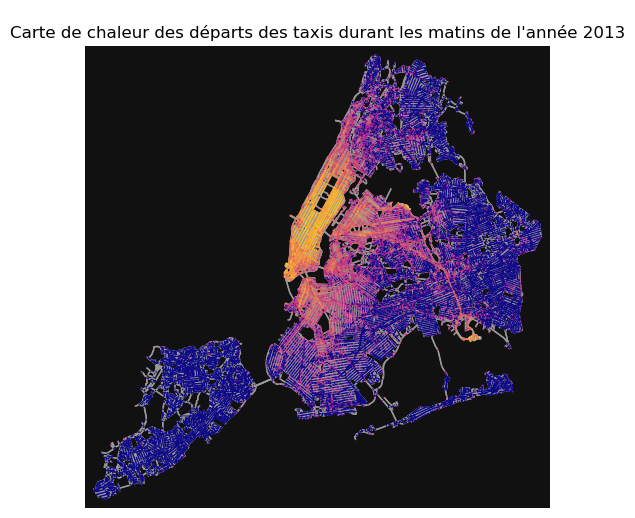

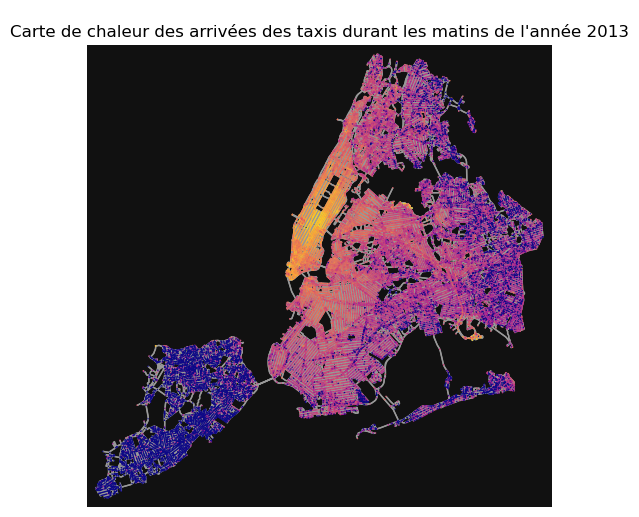

In [95]:
plot_heatmap_hour("06", "10", "matins")

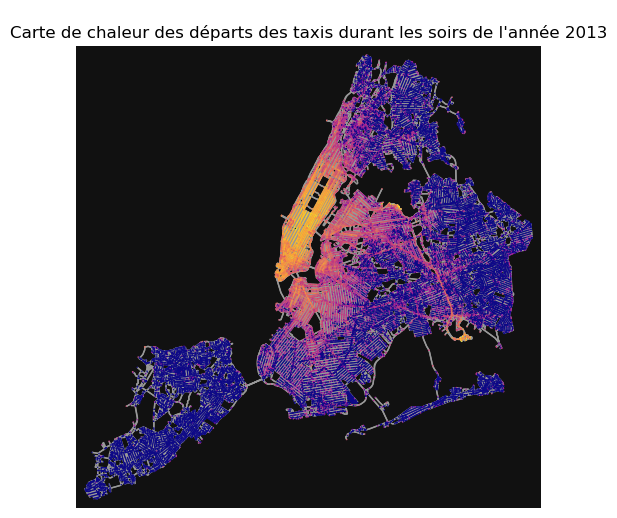

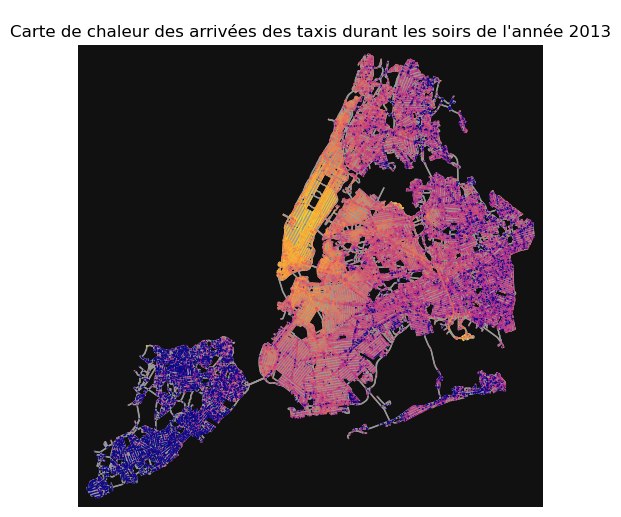

In [96]:
plot_heatmap_hour("16", "20", "soirs")

Nous n'observons pas de symétrie particulière entre les déplacements du matin et ceux du soir, en particulier pas de déplacements pendulaires. Malgré tout, au niveau de la ville entière, l'heure et le jour influe-t-ils sur le nombre de trajets ?

In [52]:
import pandas as pd
import seaborn as sns

df = pd.read_parquet("data/FOIL2013/trip_data_1.parquet")

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()  # Jour de la semaine
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_date'] = df['pickup_datetime'].dt.date  # Date sans l'heure

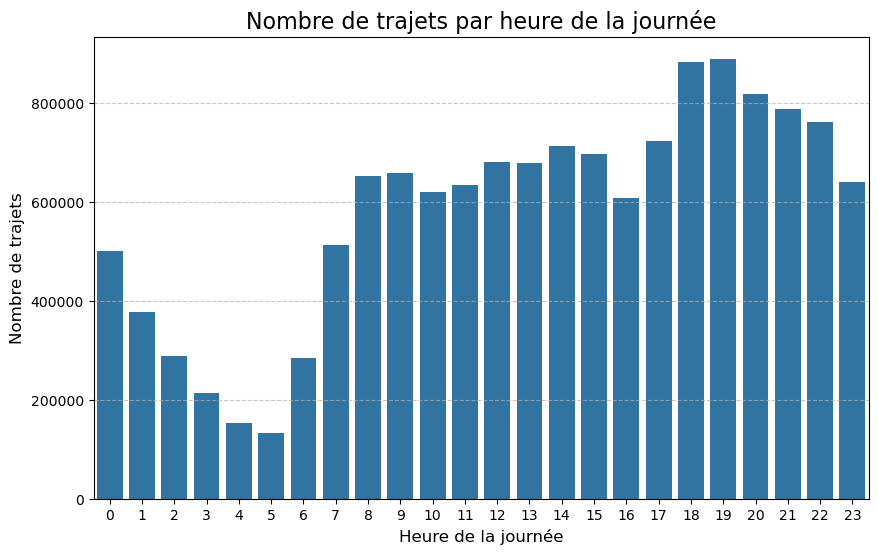

In [53]:
hourly_trips = df['pickup_datetime'].dt.hour.value_counts().sort_index()

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values)
plt.title("Nombre de trajets par heure de la journée", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Sans surprise, peu de taxis circulent entre 00h et 6h. Le pic du traffic a lieu le soir, vers 19h.

/tmp/ipykernel_30600/2800931294.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")


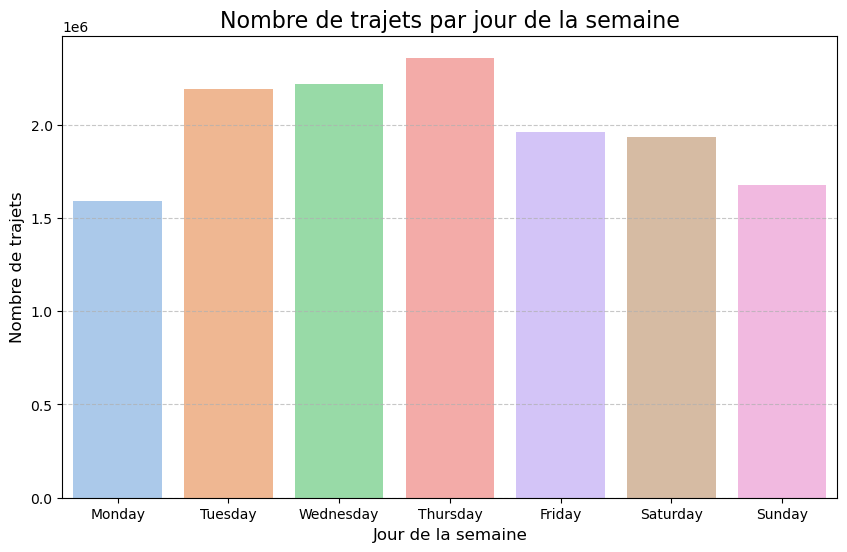

In [59]:
# Compter les trajets par jour de la semaine
weekly_trips = df['pickup_day'].value_counts() 

# Ordonner les jours de la semaine
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_trips = weekly_trips.reindex(ordered_days)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")
plt.title("Nombre de trajets par jour de la semaine", fontsize=16)
plt.xlabel("Jour de la semaine", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ce résultat est assez surprenant : il y a moins de circulation le dimanche que le lundi. Le fait que les jours actifs enregistrent une circulation plus élevé était attendu néanmoins.

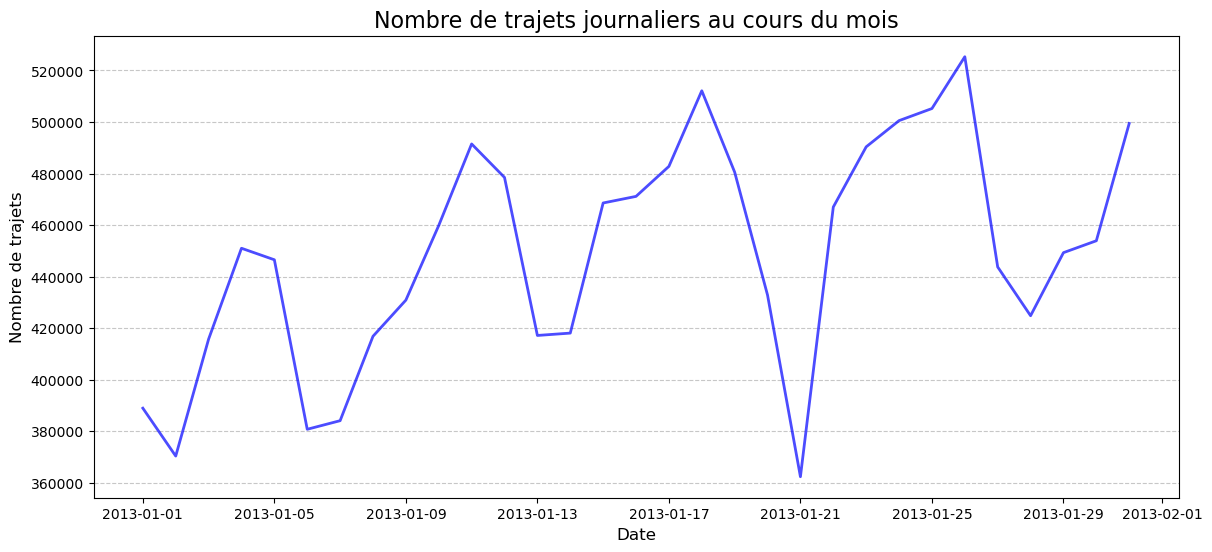

In [56]:
# Compter les trajets par jour du mois
daily_trips = df.groupby('pickup_date').size()

# Visualisation
plt.figure(figsize=(14, 6))
daily_trips.plot(color="blue", alpha=0.7, linewidth=2)
plt.title("Nombre de trajets journaliers au cours du mois", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Les creux périodiques correspondent aux lundis, corroborant ainsi le graphe précédent.
Nous en concluons qu'il est important de considérer les trajets sur sur l'année entière afin de lisser les fluctuations. Il ne semble pas très pertinent de se limiter à des tranches horaires. \

# III. Modélisation

Penchons nous sur le jeu de données "Automated Traffic Volume Counts", contenant des relevés de traffic réalisés à l'aide de bornes.

In [144]:
import pandas as pd

traffic_df = pd.read_csv("data/automated_traffic_volume_counts.csv")
traffic_df.sample(10)

,RequestID,Boro,Yr,M,D,HH,MM,Vol,SegmentID,WktGeom,street,fromSt,toSt,Direction
285619,15771,Bronx,2013,10,26,9,45,103,94366,POINT (1031200.5 243484.1),E TREMONT AV,MAYFLOWER AV,BAISLEY AV,NB
1376394,29042,Manhattan,2018,9,10,23,15,4,165004,POINT (991493.5372602648 205645.63521145438),FDR DRIVE EXIT 7 NORTHBOUND,F D R Drive,Avenue C,NB
167747,34323,Queens,2022,3,11,2,0,5,147692,POINT (1055642.3214792507 205325.99368021605),BRADDOCK AVENUE,Hillside Avenue,221 Street,WB
1007507,26997,Brooklyn,2017,5,18,20,45,178,18909,POINT (986059.1854966212 158696.90605507203),BAY PARKWAY,85 Street,86 Street,SB
1126545,11557,Manhattan,2012,12,27,17,45,340,142396,POINT (979722.1 196384.8),BATTERY PARK VIADUCT,BATTERY PLACE,BEND,SB
1359763,30546,Brooklyn,2019,6,1,22,45,133,31149,POINT (997630.2484495587 199683.07380395857),UNION AVENUE,Conselyea Street,Crosstown Line,SB
476565,7134,Staten Island,2009,6,2,8,15,193,155338,POINT (952544.5 145594.3),E/B HYLAND BLVD ( E/LEG) @ ALISON AVE,ALLISON AV,PRINCETON AV,EB
308919,15722,Brooklyn,2013,9,23,0,30,24,163723,POINT (994685.3 183565.4),WASHINGTON AV,PRESIDENT ST,EASTERN PKWY,SB
467868,29279,Bronx,2017,10,31,17,45,169,264232,POINT (1014389.7661429723 238243.70968834415),HUNTS POINT AVENUE,Pelham Line,Bruckner Boulevard,SB
383950,28006,Queens,2018,6,5,14,30,198,156766,POINT (1030108.0718283273 173404.8617156597),NORTH CHANNEL BRIDGE,Dead End,Cross Bay Boulevard,NB


Nous agrégeons pour pouvoir sommer l'ensemble des relevés faits en un même point, puis nous appliquons la normalisation définie précédemment.

In [167]:

agg_traffic_df = traffic_df.groupby("WktGeom").agg(
    Vol=("Vol", "sum"),  # Additionner les volumes
    street=("street", "first"),  # Prendre la première valeur pour "street"
    fromSt=("fromSt", "first"),
    toSt=("toSt", "first"), 
).reset_index()
counts = traffic_df.groupby("WktGeom").size().reset_index(name="count")
agg_traffic_df = pd.merge(counts, agg_traffic_df, on="WktGeom")
agg_traffic_df["street"] = agg_traffic_df["street"].apply(normalized.get)
agg_traffic_df["fromSt"] = agg_traffic_df["fromSt"].apply(normalized.get)
agg_traffic_df["toSt"] = agg_traffic_df["toSt"].apply(normalized.get)

Nous allons maintenant identifier à quel tronçon de rue appartient chaque appareil de mesure

In [195]:
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:2263", "EPSG:32618")
split_wkt_geom = agg_traffic_df["WktGeom"].str[7:-1].str.split()
agg_traffic_df["x"] = split_wkt_geom.apply(lambda x:float(x[0]))
agg_traffic_df["y"] = split_wkt_geom.apply(lambda x:float(x[1]))
agg_traffic_df["x"], agg_traffic_df["y"] = transformer.transform(agg_traffic_df["x"], agg_traffic_df["y"])
agg_traffic_df.head()

,WktGeom,count,Vol,street,fromSt,toSt,x,y
0,POINT (1000071.6 216653.5),2,286,Vernon Boulevard,36th Street,37th Street,589225.474560,4.512800e+06
1,POINT (1000075.2043563628 211424.633901344),96,8097,Jackson Avenue,Court Square,44th Drive,589244.724460,4.511207e+06
2,POINT (1000077.4410025474 211425.83073652384),480,63974,Jackson Avenue,Court Square,44th Drive,589245.401789,4.511207e+06
3,POINT (1000085.6 200045.6),385,27969,Humboldt Street,Conselyea Street,Skillman Avenue,589287.368746,4.507740e+06
4,POINT (1000091.5 231792.3),5,907,Madison Avenue,West 120th Street,West 121st Street,589178.951049,4.517413e+06


Nous utilisons la fonction Bureau of Public Roads (BPR) dont l'expression est
${f(x) = t_0(1 + \alpha(x / c)^{\beta})}$,
où ${f(x)}$ est le temps de trajet de la voie donnée avec un flux de ${x}$ conducteurs, ${t_0}$ est le temps de trajet à vide, ${c}$ la capacité de la voie et ${\alpha}$ et ${\beta}$ des paramètres à ajuster. Nous reprenons les valeurs usuelles pour ces paramètres, c'est-à-dire ${\alpha = 0,15}$ et ${\beta = 4}$. La capacité désigne le nombre de véhicules que peut accueillir un point donné de la voie pr unité de temps. Nous choisissons comme expression le nombre de voies multiplié par 2200 véhicules par heure, valeur tirée du Highway Capacity Manual. \
Essayons de vérifier la pertinence de ce modèle. \
On a ${\ln(f(x) / t_0 - 1) = \ln(\alpha) + \beta \ln(x / c)}$ donc on peut estimer les paramètres du modèle à l'aide d'une régression linéaire.

In [392]:
import scipy

nearest_edges = osmnx.distance.nearest_edges(graph, agg_traffic_df["x"], agg_traffic_df["y"])
edges_data = [graph.get_edge_data(*x) for x in nearest_edges]
lanes = []
travel_times = []
for data in edges_data:
    if "lanes" in data:
        if isinstance(data["lanes"], list):
            lanes.append(float(data["lanes"][0]))
        else:
            lanes.append(float(data["lanes"]))
    else:
        lanes.append(np.nan)
    travel_times.append(float(data.get("travel_time", np.nan)))

agg_traffic_df["lanes"] = lanes
agg_traffic_df["travel_time"] = travel_times
reg_traffic_df = agg_traffic_df.copy()
reg_traffic_df = reg_traffic_df[agg_traffic_df["Vol"] > 0]  

reg_traffic_df[reg_traffic_df["lanes"].isna()] = reg_traffic_df["lanes"].mean()
reg_traffic_df[reg_traffic_df["travel_time"].isna()] = reg_traffic_df["travel_time"].mean()
y = np.log(reg_traffic_df["count"] * 15 * 60 / reg_traffic_df["travel_time"] - 1)
flow = reg_traffic_df["Vol"] / (reg_traffic_df["count"] * 15 * 60)
x = np.log(flow / (2200 * reg_traffic_df["lanes"] / 3600))
result = scipy.stats.linregress(x, y)
print(f"alpha = {np.exp(result.intercept)}, beta = {result.slope}, R² = {result.rvalue}")


alpha = 22798.624263660047, beta = 0.40994462253265385, R² = 0.448007421905848


Les coefficients estimés sont très éloignés de leurs homologues classiques. Ce n'est pas si surprenant, puisque nous additionnons ici des flux correspondant à des relevés différents, comme si le phénomène était linéaire. Alors que, précisément, notre fonction ne l'est pas.

Nous commençons par récupérer l'intégralité des trajets réalisés durant l'année, que nous stockons dans une matrice origine-destination
Nous travaillons désormais sur le graphe simplifié.
Par la suite, nous exploitons les données d'OpenStreetMap pour récupérer des informations comme le nombre de voies ou le temps de trajet. Nous complétons les valeurs manquantes par les moyennes des colonnes. Nous nous servons de ses paramètres pour définir la capacité des voies, qui représente le nombre maximal de voitures qu'elle peut accueillir en un point par unité de temps.

In [393]:
def get_data(graph):

    simplified_graph = osmnx.simplification.consolidate_intersections(graph, tolerance=40, node_attr_aggs = {"length": np.sum, "lanes": np.mean, "speed_kph": np.mean})
    dates = pd.DataFrame({"start": [np.datetime64("2013-01-01")], "end": [np.datetime64("2013-12-31")]})
    data_processing.preprocess_datasets(simplified_graph, "data/FOIL2013")
    od_demand = data_processing.build_raw_od_matrix("data/FOIL2013", dates, simplified_graph.order())
    demand_coo = od_demand.tocoo()
    dict_demand  = {(r, c): v for r, c, v in zip(demand_coo.row, demand_coo.col, demand_coo.data)}

    lanes = []
    nodes = []
    lengths = []
    speeds_kph = []

    for u, v, data in simplified_graph.edges(data=True):
        nodes.append((u, v))
        if "lanes" in data:
            if isinstance(data["lanes"], list):
                lanes.append(float(data["lanes"][0]))
            else:
                lanes.append(float(data["lanes"]))
        else:
            lanes.append(np.nan)
        speeds_kph.append(float(data.get("speed_kph", np.nan)))
        lengths.append(float(data.get("length", np.nan)))

    data_edges = pd.DataFrame(data = {"lanes": lanes, "speed_kph": speeds_kph, "length": lengths}, index = pd.MultiIndex.from_tuples(nodes, names=["u", "v"]))

    for col in data_edges.columns:
        data_edges[data_edges[col].isna()] = data_edges[col].mean()

    data_edges["capacity"] = 2200 * data_edges["lanes"] / 3600
    data_edges["travel_time"] = data_edges["length"] / (data_edges["speed_kph"] * 1000 / 3600)

    return simplified_graph, data_edges, dict_demand

Nous définissons les paramètres utiles au modèle, en particulier la fonction BPR et ses paramètres.

In [395]:
import graph_tool.all as gt
import networkx as nx

def get_solver(data_edges, graph):

    a = 0.15
    b = 4

    gt_graph = gt.Graph(nx.to_scipy_sparse_array(graph))
    A, B, C, T0, back = [gt_graph.new_edge_property("float", val=0) for _ in range(5)]
    num_edges = gt_graph.num_edges()

    A.a = a * np.ones(num_edges)
    B.a = b * np.ones(num_edges)

    for row in data_edges.itertuples(index=True, name='Pandas'):
        edge = gt_graph.edge(*row.Index)
        C[edge] = row.capacity
        T0[edge] = row.travel_time
    params = [A, B, C, T0]
    return gt_graph, solver.ITAPAS(gt_graph, params, back, solver.bpr_function)

In [405]:
def solve(solver, demand):
        params={
            "epsilon": 1e-12,
            "theta": 1e-12,
            "mu": 1e-3,
            "nu": 0.5,
            "dg": 1e-6,
            "time": 120_000,
            "iter": 200,
            "out_flag": True,
            }
        link_flow, link_flow_node = itapas_solver.assign(demand, params = params)
        return link_flow

# IV. Résultats et conclusion

D'après la page Wikipédia sur le paradoxe de Braess, on a observé une diminution de la congestion suite à la fermeture de la 42ème rue à New York en 1990. Observe-t-on un phénomène similaire ? Et augmenter la limitation de vitesse diminue-t-il le temps de trajet total selon notre modèle ?

In [401]:
graph_without_42 = graph.copy()

def is_42nd_avenue(edge):
    return "42nd Avenue" in edge['name'] if isinstance(edge["name"], list) else "42nd Avenue" == edge["name"]

edges_to_remove = edges[edges.apply(is_42nd_avenue, axis=1)]
for index, row in edges_to_remove.iterrows():    
    graph_without_42.remove_edge(*index)

print(f"{graph.number_of_edges() - graph_without_42.number_of_edges()} arêtes retirées")

sped_up_graph = graph.copy()

print(f"Ancienne vitesse moyenne : {osmnx.graph_to_gdfs(sped_up_graph, nodes=False, edges=True)["speed_kph"].mean()}")

for u, v, key, data in sped_up_graph.edges(keys=True, data=True):
    if "speed_kph" in data:
        data["speed_kph"] += 10

print(f"Nouvelle vitesse moyenne : {osmnx.graph_to_gdfs(sped_up_graph, nodes=False, edges=True)["speed_kph"].mean()}")

79 arêtes retirées
Ancienne vitesse moyenne : 40.03138685155923
Nouvelle vitesse moyenne : 50.03138685155925


La résolution est longue (environ 2h30)

In [ ]:
graphs = [graph, graph_without_42, sped_up_graph]
solvers = [get_solver(datas_edges[i], simplified_graph[i]) for i in range(3)]
gt_graphs, solvers = [[solvers[i][j] for i in range(3)] for j in range(2)]
datas = [get_data(x) for x in graphs]
simplified_graphs, datas_edges, od_demands = [[datas[i][j] for i in range(3)] for j in range(3)]
link_flows = [solvers[i].assign(od_demands[i]) for i in range(3)]

Visualisons l'assignation pour le réseau original.

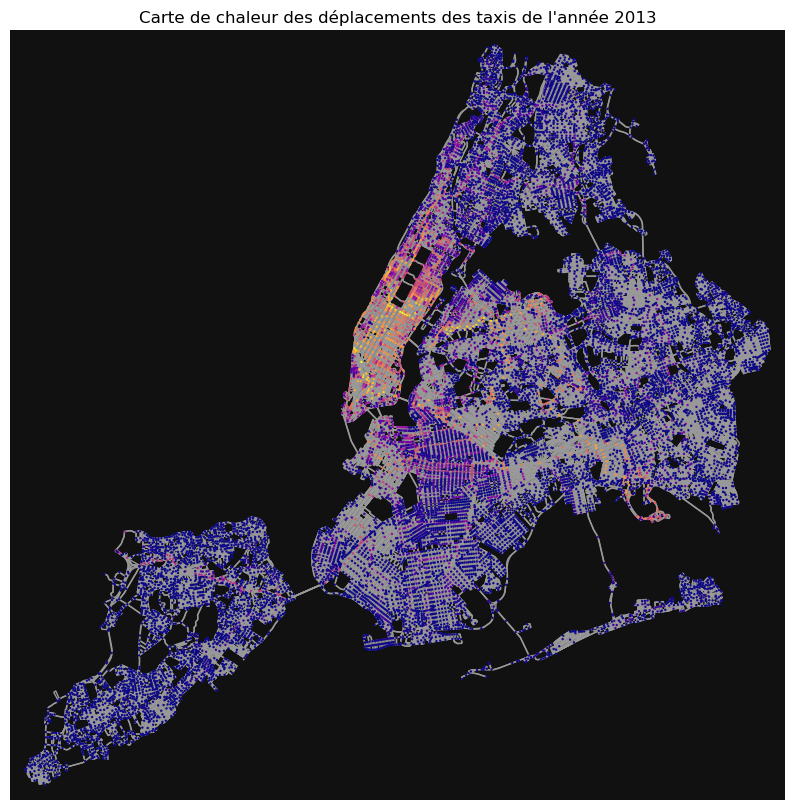

In [415]:
gt_graph = gt_graphs[0]
link_flow = link_flows[0]
vertex_flow = gt_graph.new_vertex_property("float", val=0)

for edge in gt_graph.edges():

    vertex_flow[edge.source()] += link_flow[edge]
    vertex_flow[edge.target()] += link_flow[edge]

def plot_heatmap(array, title):
    cmap = plt.get_cmap("plasma")
    norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
    colors = [mcolors.to_hex(cmap(norm(x))) for x in array]
    fig, ax = osmnx.plot.plot_graph(simplified_graphs[0], node_color=colors, node_size=3, figsize=(10, 10), show=False, close=False)
    ax.set_title(title)
    plt.show()

plot_heatmap(np.log1p(vertex_flow), "Carte de chaleur des déplacements des taxis de l'année 2013")

Il faut garder à l'esprit que, contrairement aux premières cartes de chaleur, celle-ci donne le nombre de taxis passant par un sommet donné, ce qui comprend les trajets intermédiaires (alors que les précédentes ne n'incluaient que les sommets de départ et d'arrivée). La carte est difficile à interpréter. Comparons les temps de trajets agrégés.

In [428]:
travel_times = [np.sum(solver.bpr_function(link_flows[i], [x.a for x in solvers[i].link_param])[1]) for i in range(3)]
print(f"Temps de trajet agrégé du graphe original : {travel_times[0] / (24 * 3600 * 365)} ans")
print(f"Temps de trajet agrégé du graphe sans la 42ème avenue : {travel_times[1] / (24 * 3600 * 365)} ans")
print(f"Temps de trajet agrégé du graphe où les limitations de vitesse sont plus élevées de 10 km/h : {travel_times[2] / (24 * 3600 * 365)} ans")

Temps de trajet agrégé du graphe original : 1688.5645369411088 ans
Temps de trajet agrégé du graphe sans la 42ème avenue : 1688.316131204185 ans
Temps de trajet agrégé du graphe où les limitations de vitesse sont plus élevées de 10 km/h : 1254.3864868741268 ans


L'interprétation individuelle de ces temps est assez difficile, puisqu'ils sont trop élevés pour représenter des temps individuels mais trop faibles pour représenter la somme des temps de trajets des voyageurs. Il s'agit là peut-être d'une erreur dans la modélisation ou dans les paramètres.\
Nous pouvons malgré tout les comparer, et constater que nous n'obtenons pas de résultats contre-intuitifs, ce qui était attendu mais décevant, et que l'on ne peut pas vraiment justifier.

En définitive, discutons des limites de la modélisation proposée. \
Premièrement, les données utilisées ne sont pas cohérentes et incomplètes. Les trajets des taxis datent de 2013 alors que la carte date de 2025. Le réseau que nous utilisons est une version simplifiée donc on a pu perdre des données importantes. De plus, nous nous limitons ici aux taxis comme véhicules, alors qu'il y a d'autres véhicules, et qui ont certainement des tendances de déplacement très différentes. \
Deuxièmement, concernant la modélisation, nous n'avons aucun moyen de tester la pertinence de la fonction BPR, et ne pouvons pas non plus estimer ses paramètres.  Le modèle fait des hypothèses fortes sur les conducteurs, comme leur connaissance parfaite du réseau à tout instant pour emprunter le chemin le plus rapide (quoiqu'elle devient raisonnable avec l'avènement des GPS connectés). Enfin, il ne permet que de déterminer un équilibre, on ne sait rien de l'évolution du traffic, ni même si l'on atteindra effectivement un équilibre.